# Solar Flare Prediction Using Solar Active Region Data

This notebook covers the first stage of the project:
- downloading NOAA flare reports and SHARP active-region parameters
- cleaning and aligning the datasets
- creating a `flare_next_24h` label
- generating exploratory figures and summary statistics


## Physical Interpretation of the Features

- `USFLUX`: total unsigned magnetic flux. Larger values usually indicate stronger magnetic activity.
- `AREA_ACR`: deprojected active-region area in micro-hemispheres. Larger regions tend to host more complex magnetic structures.
- `TOTUSJH` and `TOTUSJZ`: measures of current helicity and current density, linked to magnetic non-potentiality.
- `MEANPOT` and `R_VALUE`: proxies for magnetic free energy and polarity inversion line complexity.
- `MEANGBT`, `MEANGBZ`, `MEANGBH`: mean magnetic field gradients, useful for identifying stressed field configurations.


In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_download import download_stage_one_data, ensure_project_dirs
from src.exploration import compute_mutual_information, compute_pearson_correlations, generate_eda_figures, summarize_dataset
from src.preprocessing import prepare_modeling_dataset

ensure_project_dirs(PROJECT_ROOT)
pd.set_option('display.max_columns', 50)


## Download Data

Adjust the year range and SHARP time interval as needed. The SHARP query requires the `drms` package.


In [2]:
START_DATE = '2026-02-01'
END_DATE = '2026-02-10'
START_TIME = '2026.02.01_00:00:00_TAI'
END_TIME = '2026.02.10_23:59:59_TAI'

# Uncomment to download fresh files.
# download_stage_one_data(
#     project_root=PROJECT_ROOT,
#     start_date=START_DATE,
#     end_date=END_DATE,
#     start_time=START_TIME,
#     end_time=END_TIME,
#     cadence='12h',
# )


## Load and Prepare the Datasets

The pipeline expects NOAA flare report text files in `data/noaa_flare_reports/` and a SHARP parameter table in `data/sharp_parameters.csv`.


In [3]:
flare_files = sorted((PROJECT_ROOT / 'data' / 'noaa_flare_reports').glob('*.txt'))
sharp_file = PROJECT_ROOT / 'data' / 'sharp_parameters.csv'

flare_df, active_df, labeled_df = prepare_modeling_dataset(flare_files, sharp_file)

print('Flare records:', len(flare_df))
print('Active-region snapshots:', len(active_df))
print('Labeled samples:', len(labeled_df))


Flare records: 137
Active-region snapshots: 208
Labeled samples: 208


In [4]:
summary_df = summarize_dataset(flare_df, active_df, labeled_df)
summary_df


,metric,value
0,flare_events,137.000000
1,active_region_snapshots,208.000000
2,unique_active_regions,19.000000
3,positive_labels,31.000000
4,positive_rate,0.149038


In [5]:
labeled_df.head()


,observation_time,noaa_active_region,USFLUX,AREA_ACR,TOTUSJH,TOTUSJZ,ABSNJZH,SAVNCPP,MEANPOT,R_VALUE,TOTBSQ,MEANGBT,MEANGBZ,MEANGBH,flare_next_24h
0,2026-02-01 00:00:00+00:00,4349,4.032213e+22,1304.599243,1752.747,4.153788e+13,49.210,4.188340e+12,1485.0030,3.747,NaN,89.376,92.444,29.970,0
1,2026-02-01 12:00:00+00:00,4349,3.333757e+22,928.606567,1434.537,3.275247e+13,111.718,1.034279e+13,1139.0610,4.792,NaN,96.954,96.673,29.940,0
2,2026-02-02 00:00:00+00:00,4349,2.785722e+22,626.473816,1003.272,2.451029e+13,69.786,4.673532e+12,951.8146,3.916,NaN,80.678,81.068,25.235,0
3,2026-02-02 12:00:00+00:00,4349,1.847716e+22,350.015228,712.985,1.638126e+13,125.215,6.670391e+12,930.5786,4.310,NaN,87.293,87.822,24.993,0
4,2026-02-03 00:00:00+00:00,4349,9.338511e+21,192.085022,323.684,7.642705e+12,57.532,2.338189e+12,818.2908,3.414,NaN,76.185,77.146,22.701,0


## Statistical Analysis

These two tables highlight linear associations (Pearson correlation) and more general nonlinear relationships (mutual information) between the magnetic features and the flare label.


In [6]:
pearson_corr = compute_pearson_correlations(labeled_df)
mutual_info = compute_mutual_information(labeled_df)

display(pearson_corr.to_frame('pearson_with_flare_next_24h'))
display(mutual_info.to_frame('mutual_information'))


,pearson_with_flare_next_24h
TOTUSJH,0.639852
TOTUSJZ,0.616212
AREA_ACR,0.535676
ABSNJZH,0.507051
USFLUX,0.487867
MEANPOT,0.479479
SAVNCPP,0.392948
MEANGBH,0.330248
R_VALUE,0.249530
MEANGBZ,0.064802


,mutual_information
TOTUSJZ,0.207278
USFLUX,0.177586
TOTUSJH,0.176996
AREA_ACR,0.161086
MEANPOT,0.153351
R_VALUE,0.146556
ABSNJZH,0.124799
MEANGBZ,0.111257
MEANGBT,0.105016
SAVNCPP,0.081748


## Visualizations

The plotting utility saves the figures to the `figures/` folder and returns the paths.


In [7]:
figure_paths = generate_eda_figures(flare_df, labeled_df, PROJECT_ROOT / 'figures')
pd.Series({name: str(path) for name, path in figure_paths.items()}, name='saved_figure').to_frame()


,saved_figure
flare_class_histogram,C:\Users\stude\OneDrive\Desktop\Projects\Solar...
magnetic_field_strength_distribution,C:\Users\stude\OneDrive\Desktop\Projects\Solar...
active_region_area_distribution,C:\Users\stude\OneDrive\Desktop\Projects\Solar...
parameter_correlation_heatmap,C:\Users\stude\OneDrive\Desktop\Projects\Solar...
magnetic_flux_vs_flare_occurrence,C:\Users\stude\OneDrive\Desktop\Projects\Solar...


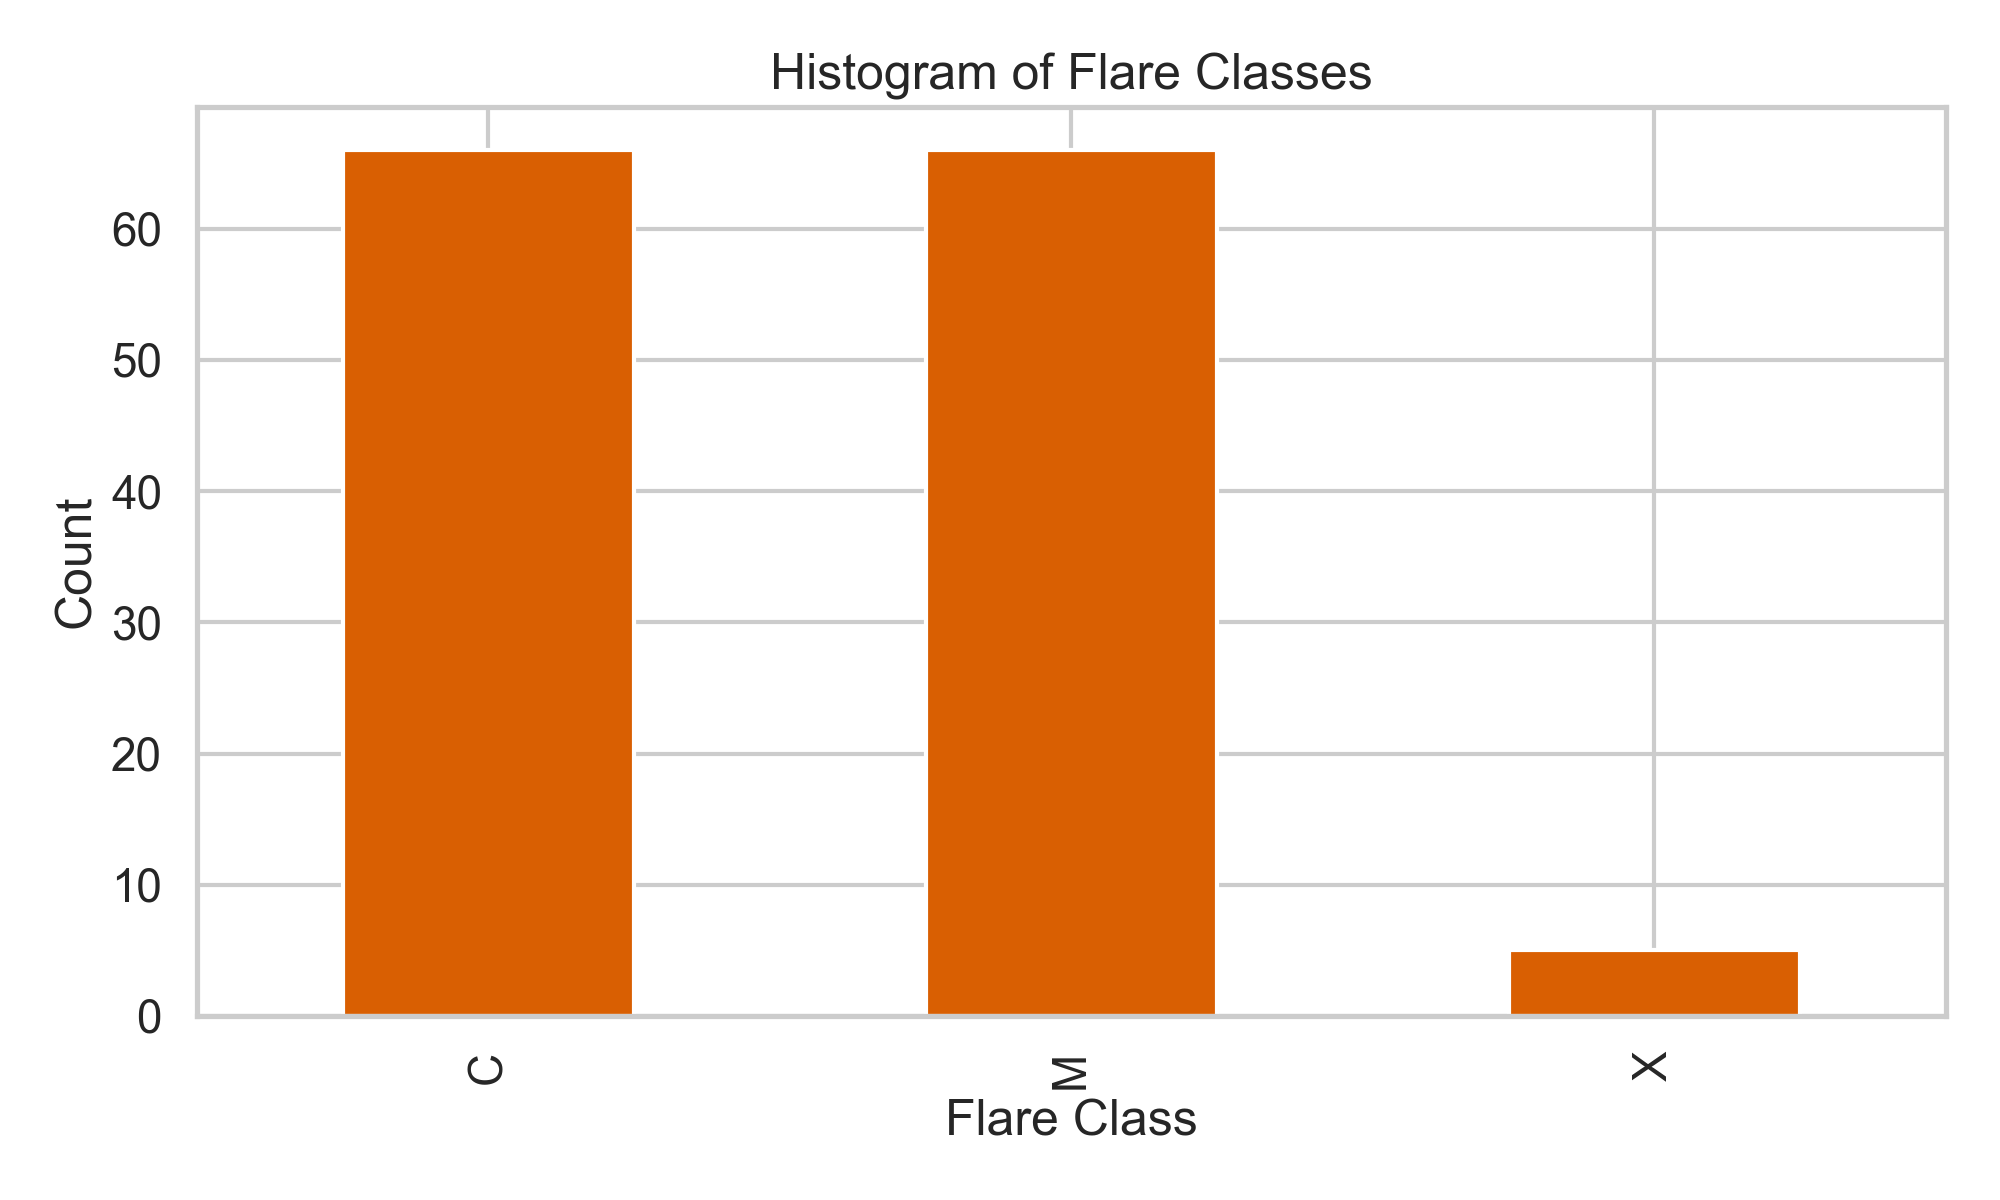

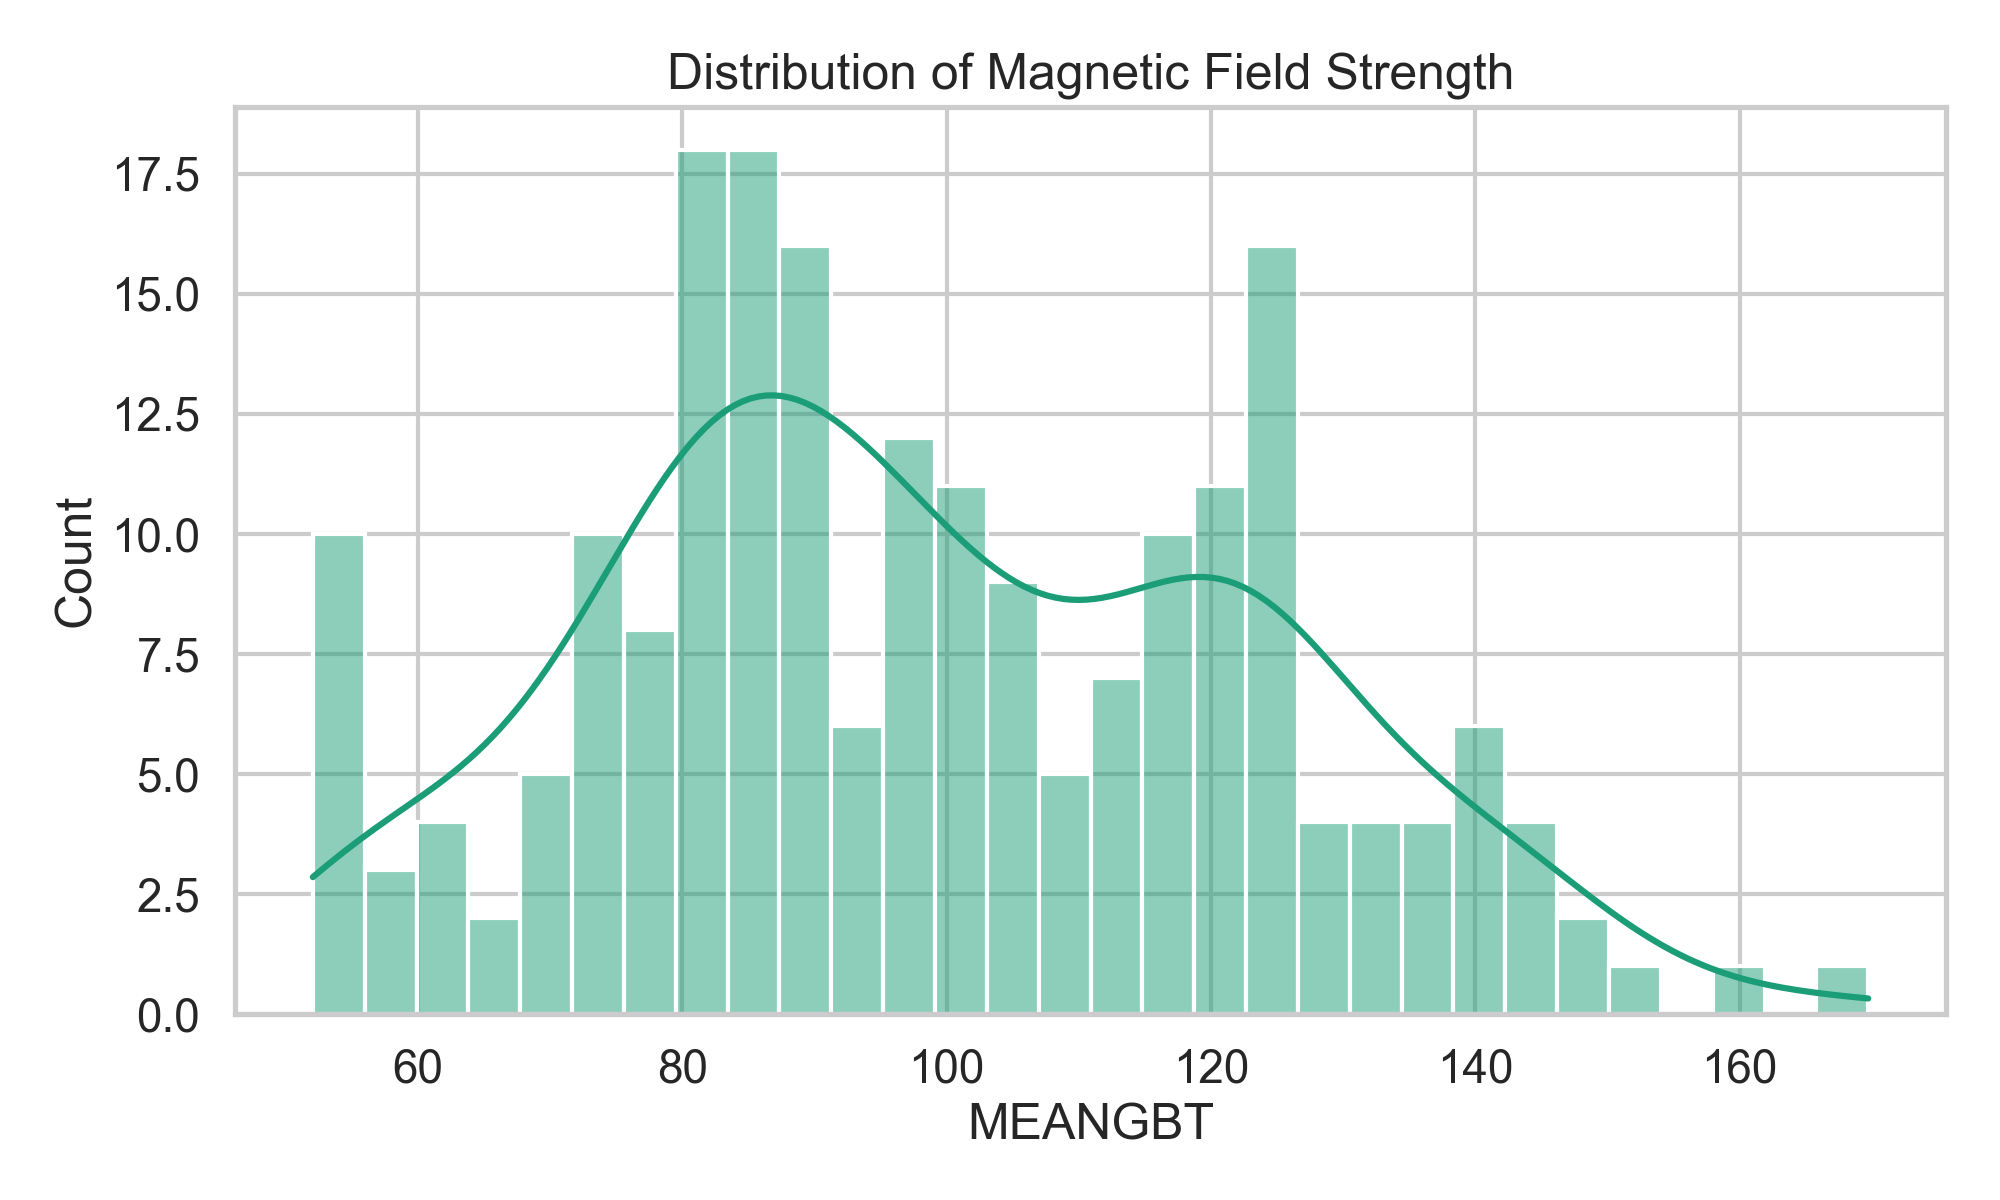

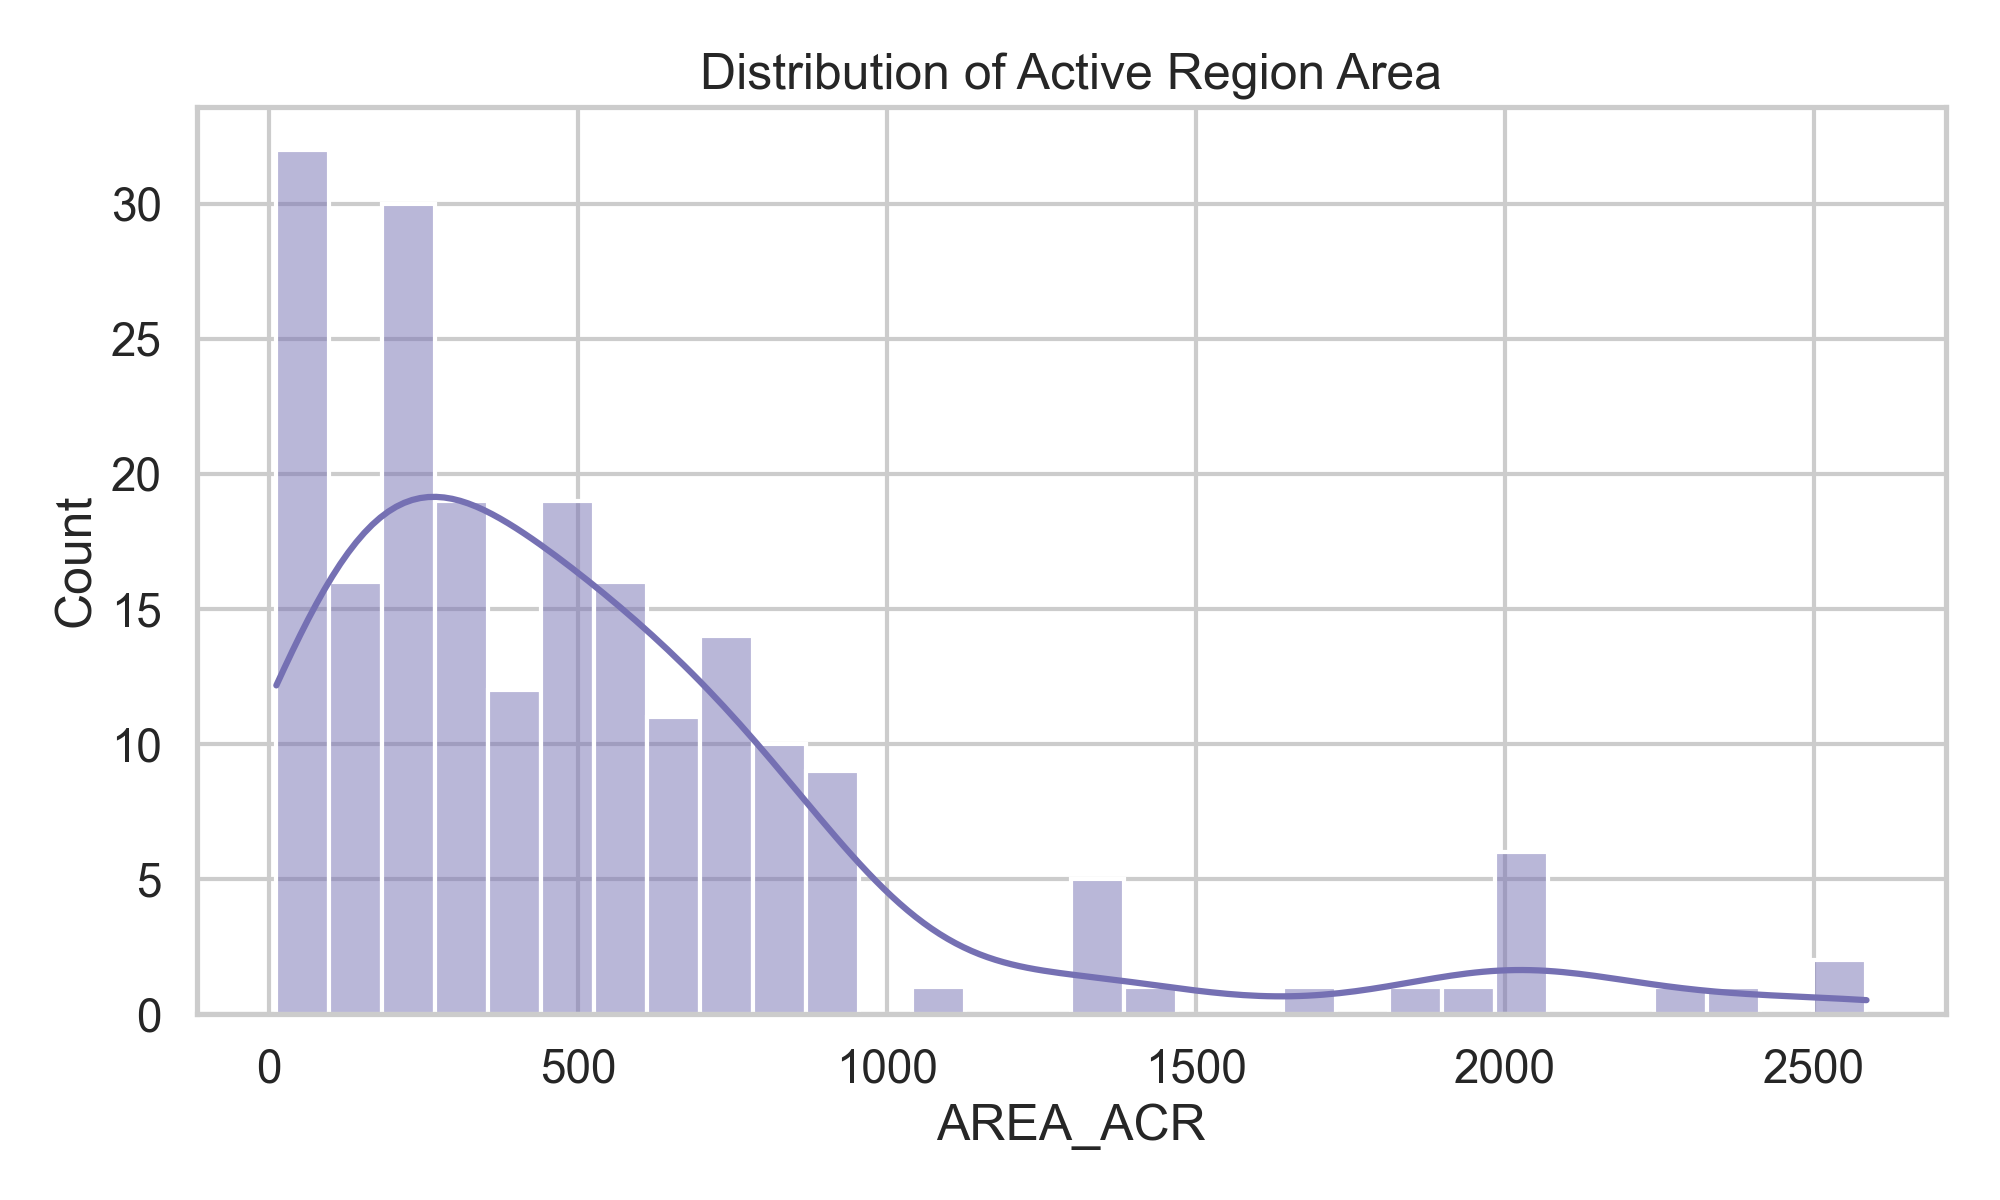

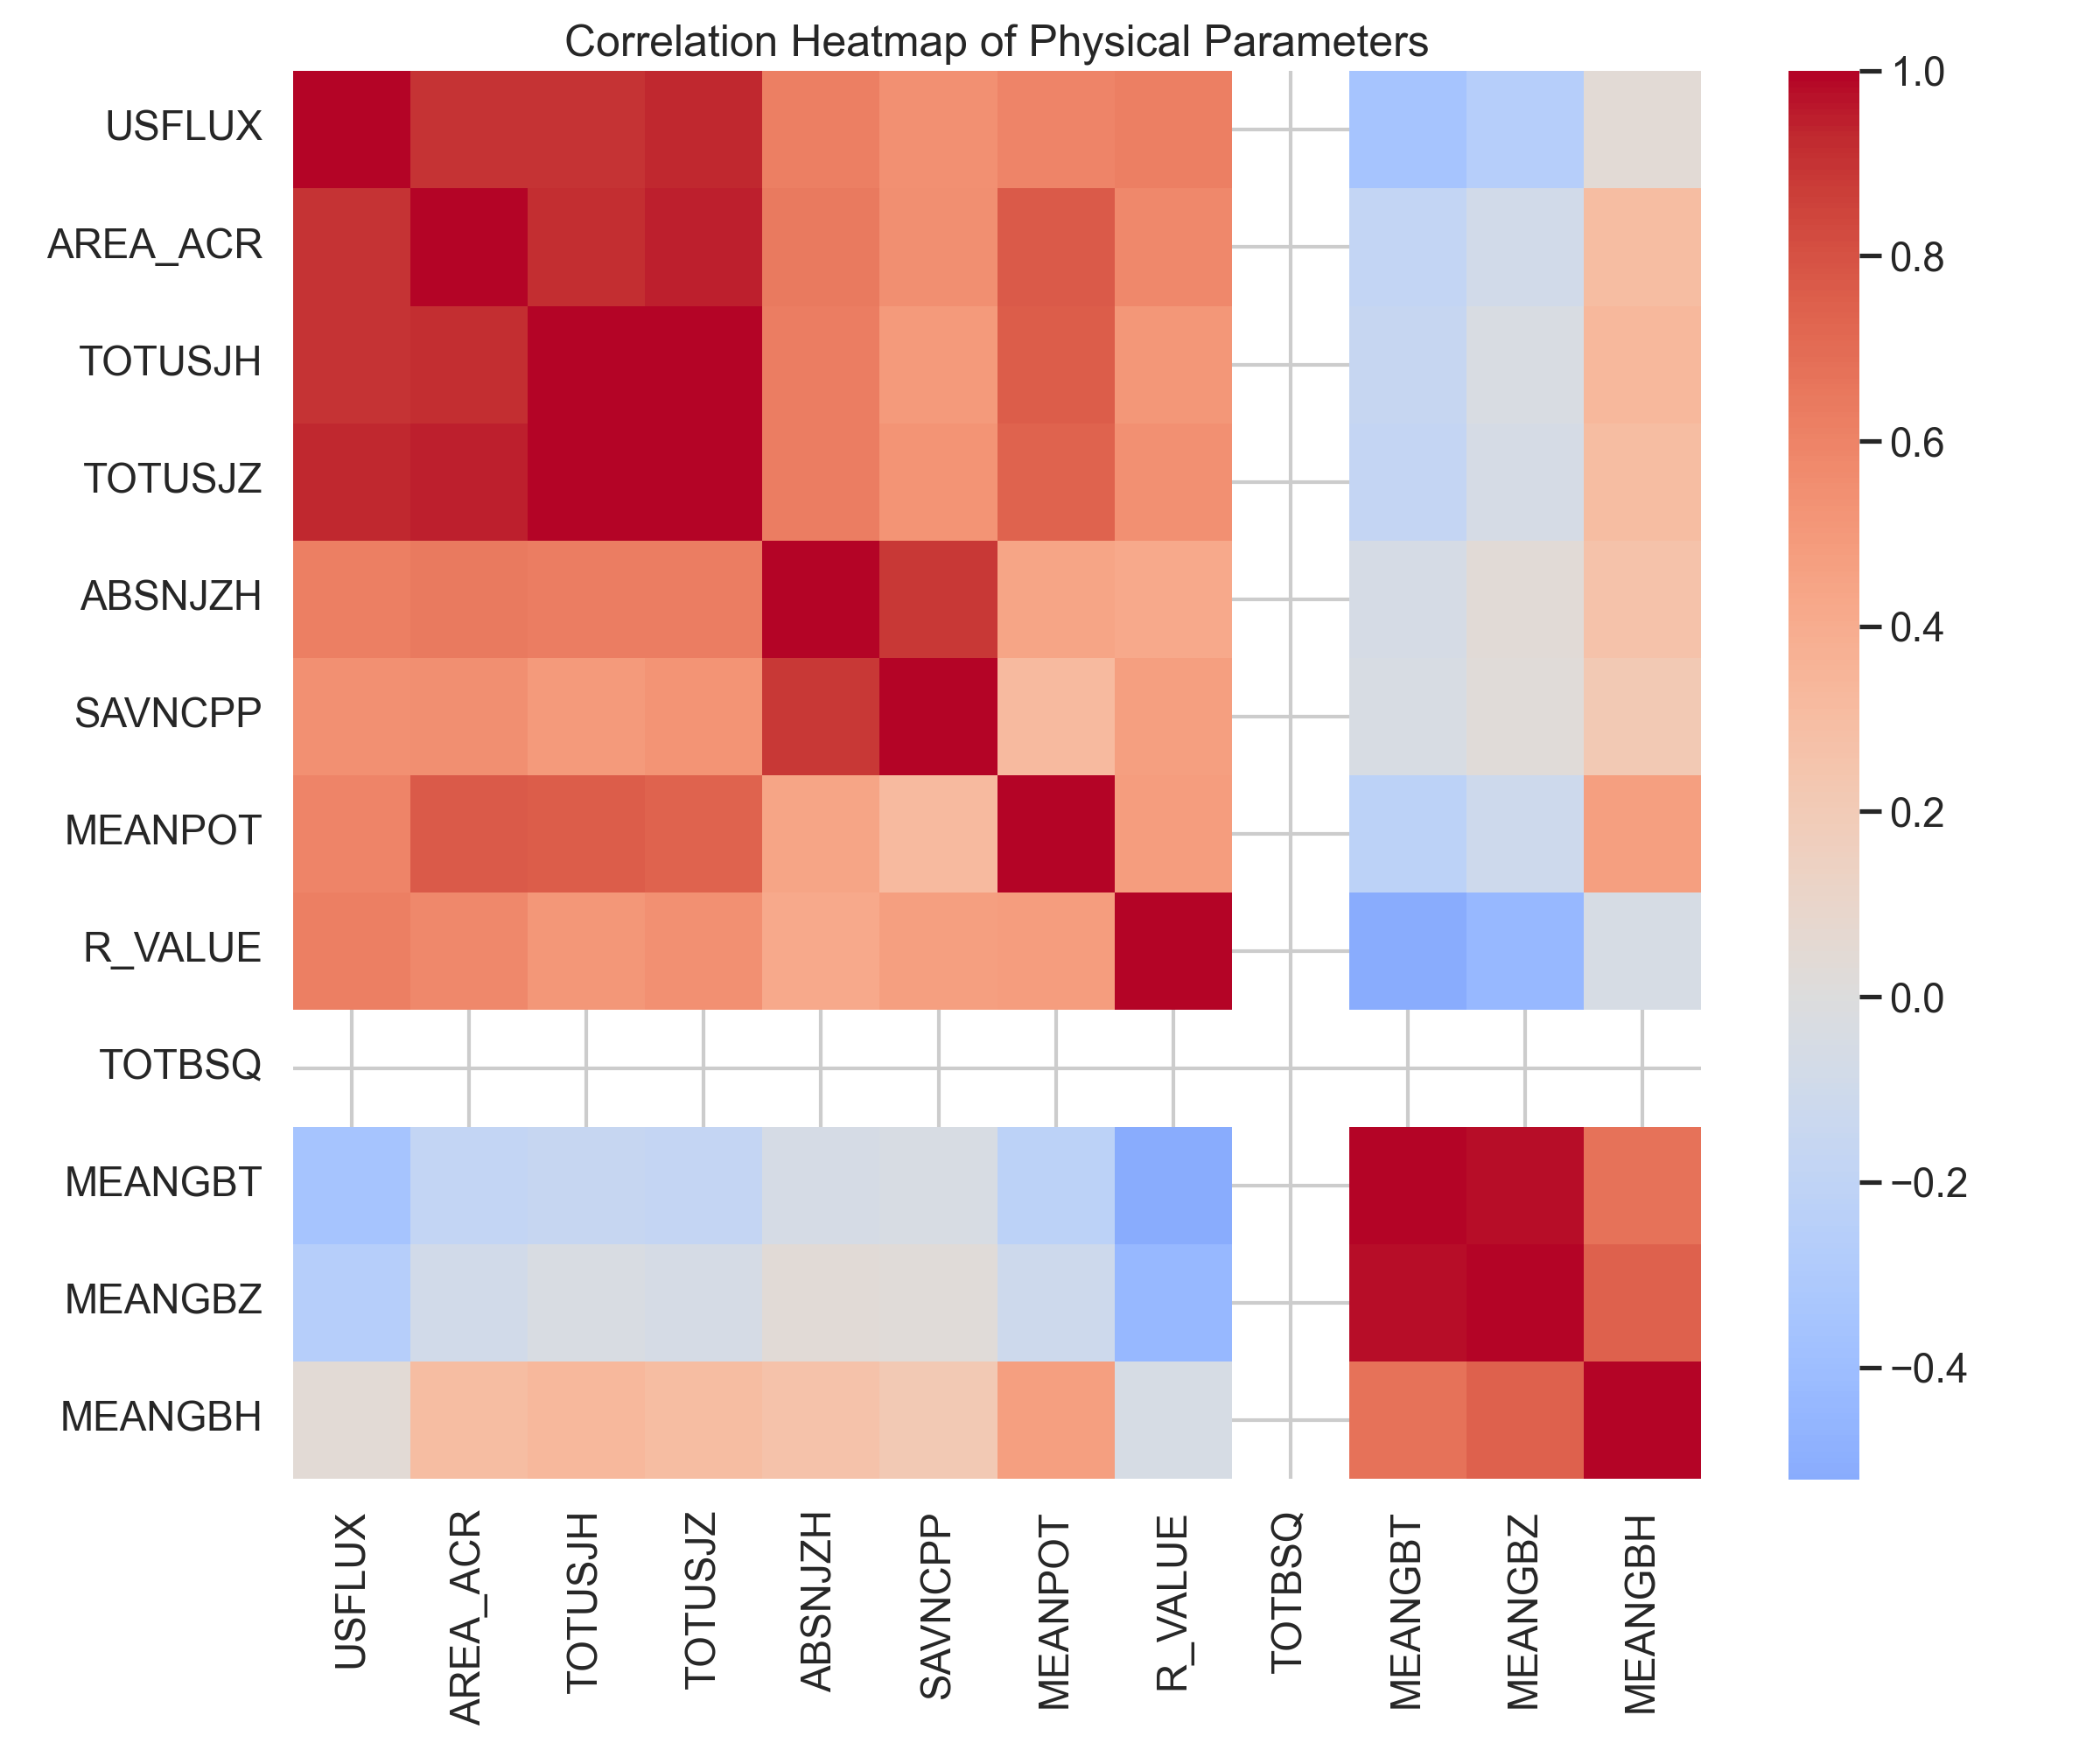

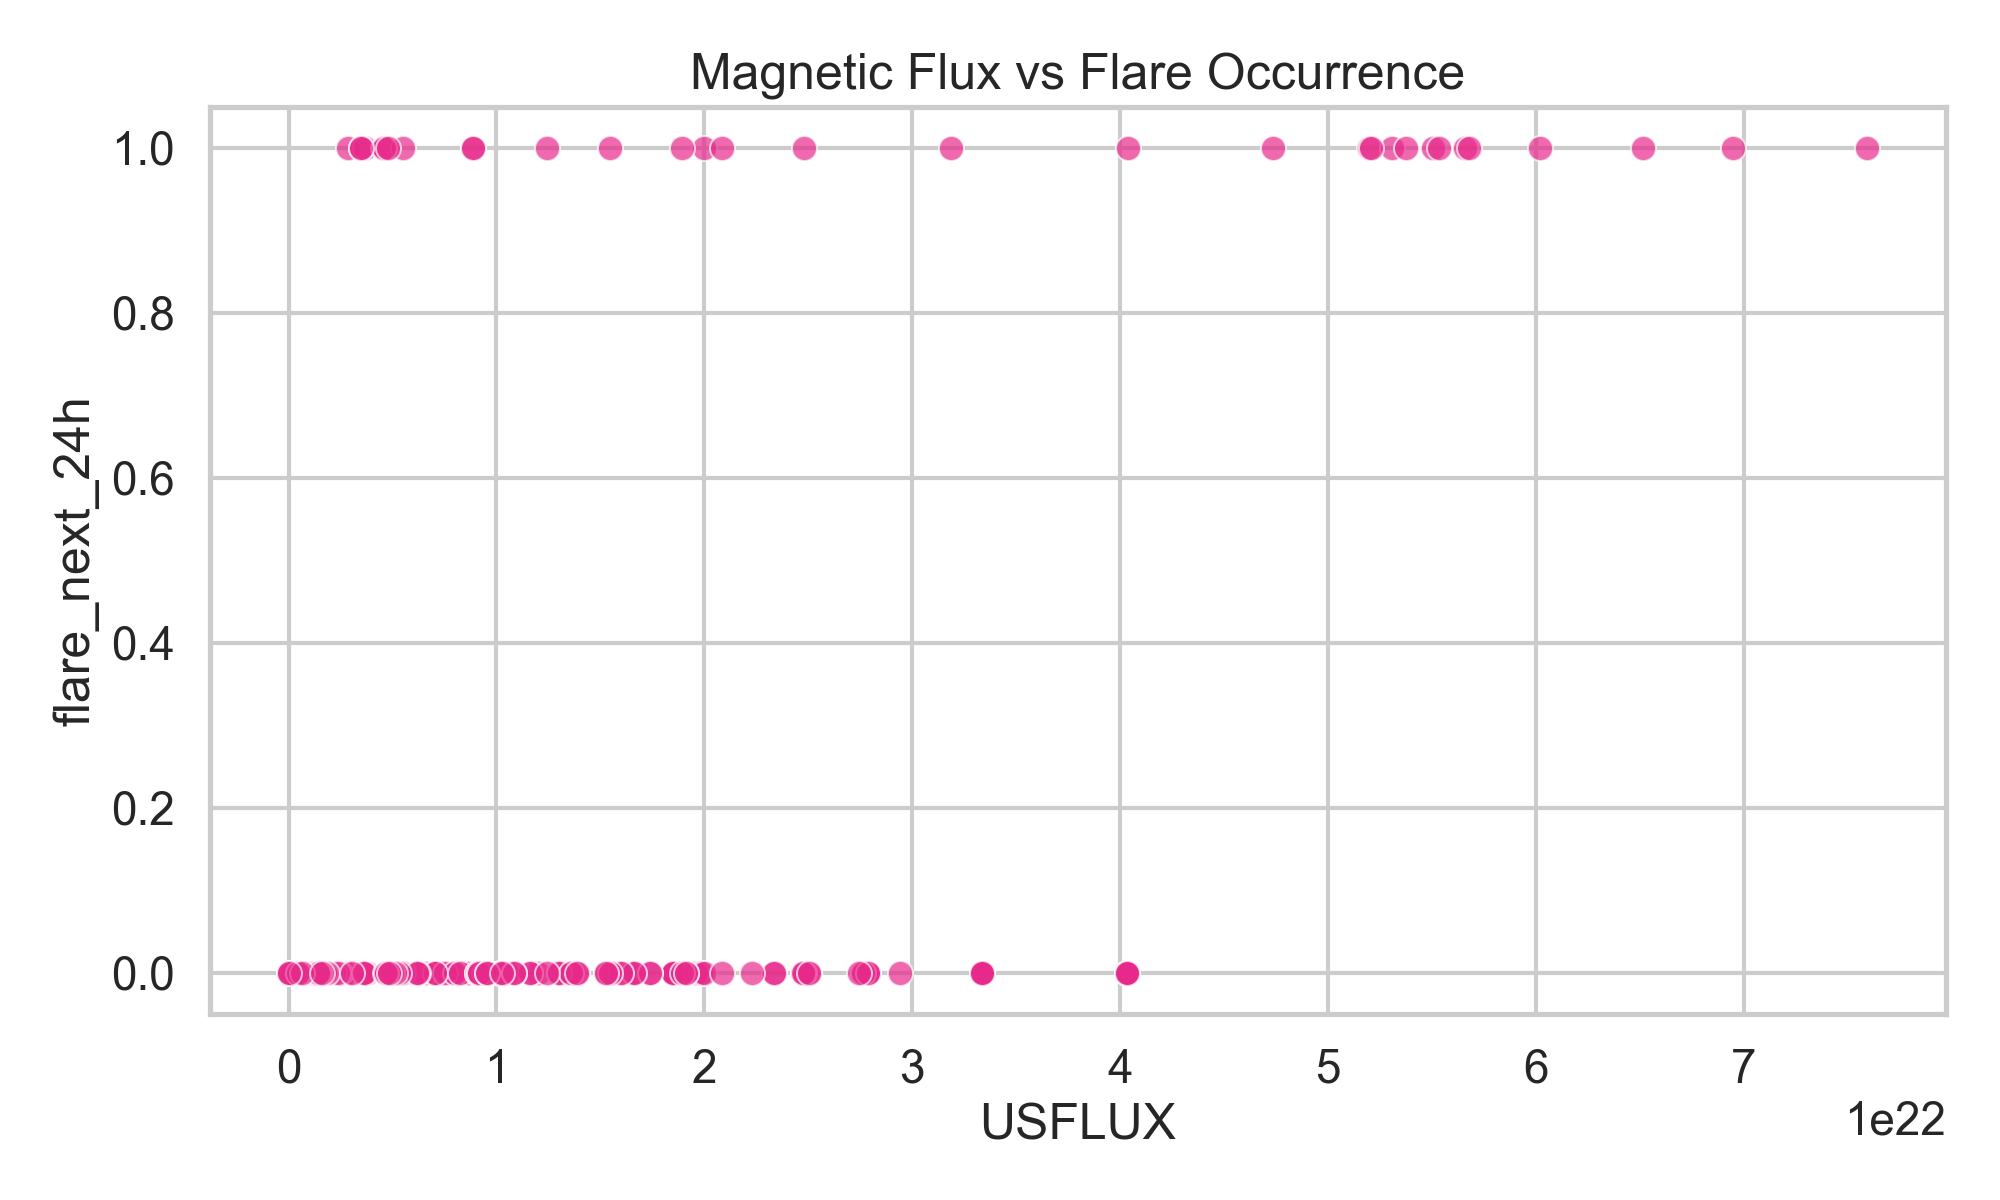

In [8]:
from IPython.display import Image, display

for path in figure_paths.values():
    display(Image(filename=str(path)))
